# Urban Segmentation — Training Comparison

Five architectures in one notebook:
| # | Architecture | Backbone | Upsampling | Skip connections |
|---|---|---|---|---|
| 1 | **UNet** | from scratch | Transposed conv | Yes (concat) |
| 2 | **VGG16-UNet** | VGG16 pretrained | Transposed conv | Yes (concat) |
| 3 | **SegNet** | from scratch | MaxUnpool2d (indices) | No |
| 4 | **ResNet34-UNet** | ResNet34 pretrained | Transposed conv | Yes (concat) |
| 5 | **ResNet50-UNet** | ResNet50 pretrained | Transposed conv | Yes (concat) |

All runs are tracked in the same MLflow experiment `urban-segmentation`.

**To train:** edit the `CONFIG` cell, then run all cells (Kernel → Restart & Run All).

## 1. Imports & paths

In [1]:
import os
import sys

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as tv_models
import numpy as np
import mlflow
import mlflow.pytorch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Resolve the repo root regardless of where the notebook is launched from
# (e.g. from the repo root or from notebooks/). Walk up until we find src/.
PROJECT_ROOT = os.getcwd()
while not os.path.isdir(os.path.join(PROJECT_ROOT, "src")) and os.path.dirname(PROJECT_ROOT) != PROJECT_ROOT:
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)

SRC_DIR = os.path.join(PROJECT_ROOT, "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

Project root: c:\Users\DFILATOVA\Desktop\CityVision
CUDA available: True
Device: NVIDIA RTX 2000 Ada Generation Laptop GPU


## 2. Configuration — choose your model here

In [ ]:
# ─── EDIT THIS CELL ───────────────────────────────────────────────────────────
# ARCHITECTURE: "UNet" | "VGG16-UNet" | "SegNet" | "ResNet34-UNet" | "ResNet50-UNet"
ARCHITECTURE = "SegNet"

BATCH_SIZE = 4
EPOCHS     = 20

# Learning rate: VGG16-UNet uses split LR (encoder ×0.1), others use a single LR
LR = 1e-3   # use 1e-3 for SegNet (BN helps converge faster from scratch)

IMG_ROOT  = os.path.join(PROJECT_ROOT, "data/cityscapes/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit")
MASK_ROOT = os.path.join(PROJECT_ROOT, "data/cityscapes/P8_Cityscapes_gtFine_trainvaltest/gtFine")
# ──────────────────────────────────────────────────────────────────────────────

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT_NAME = {"UNet": "unet_best.pth", "VGG16-UNet": "vgg_best.pth", "SegNet": "segnet_best.pth",
                   "ResNet34-UNet": "resnet_best.pth", "ResNet50-UNet": "resnet50_best.pth"}[ARCHITECTURE]
CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, "backend", "model", CHECKPOINT_NAME)
print(f"Architecture : {ARCHITECTURE}")
print(f"Device       : {DEVICE}")
print(f"Checkpoint   : {CHECKPOINT_PATH}")

## 3. Dataset & dataloader

In [3]:
from dataloader import create_dataloaders

train_loader, val_loader = create_dataloaders(IMG_ROOT, MASK_ROOT, batch_size=BATCH_SIZE)
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

# Quick sanity check
imgs, masks = next(iter(train_loader))
print(f"Image batch : {imgs.shape}  dtype={imgs.dtype}")
print(f"Mask batch  : {masks.shape}  dtype={masks.dtype}  unique ids sample={masks[0].unique()[:8].tolist()}")

Train batches: 744  |  Val batches: 125
Image batch : torch.Size([4, 3, 512, 1024])  dtype=torch.float32
Mask batch  : torch.Size([4, 512, 1024])  dtype=torch.int64  unique ids sample=[1, 3, 4, 6, 8, 11, 17, 20]


## 4. Shared utilities

In [4]:
TARGET_CLASSES = {7:1, 11:2, 21:3, 23:4, 24:5, 26:6, 20:7, 33:8}
CLASS_NAMES    = ["background","road","building","vegetation",
                  "sky","person","car","traffic_sign","bicycle"]
NUM_CLASSES    = 9


def remap_mask(mask):
    new_mask = torch.zeros_like(mask)
    for src, dst in TARGET_CLASSES.items():
        new_mask[mask == src] = dst
    return new_mask


# Class weights aligned with the segmentation package / src training scripts.
class_weights = torch.tensor(
    [0.5, 1.0, 1.0, 1.0, 1.0, 2.5, 1.0, 3.0, 3.0], dtype=torch.float32
)


class DiceLoss(nn.Module):
    """Weighted Dice — per-class scores averaged using class_weights."""
    def __init__(self, class_weights, smooth=1.0):
        super().__init__()
        w = class_weights / class_weights.sum() * len(class_weights)
        self.register_buffer("weights", w)
        self.smooth = smooth

    def forward(self, logits, targets):
        probs   = torch.softmax(logits, dim=1)
        one_hot = torch.zeros_like(probs).scatter_(1, targets.unsqueeze(1), 1.0)
        dims    = (0, 2, 3)
        inter   = (probs * one_hot).sum(dim=dims)
        denom   = (probs + one_hot).sum(dim=dims)
        dice    = (2.0 * inter + self.smooth) / (denom + self.smooth)
        return 1.0 - (dice * self.weights).sum() / self.weights.sum()


class CombinedLoss(nn.Module):
    """CE(weighted) + Dice(weighted) — matches the segmentation package."""
    def __init__(self, class_weights):
        super().__init__()
        self.ce   = nn.CrossEntropyLoss(weight=class_weights)
        self.dice = DiceLoss(class_weights)

    def forward(self, logits, targets):
        return self.ce(logits, targets) + self.dice(logits, targets)


criterion = CombinedLoss(class_weights)


class SegmentationMetrics:
    def __init__(self, num_classes):
        self.num_classes = num_classes
        self.confusion = np.zeros((num_classes, num_classes), dtype=np.int64)

    def update(self, preds, targets):
        preds   = preds.cpu().numpy().ravel()
        targets = targets.cpu().numpy().ravel()
        mask    = (targets >= 0) & (targets < self.num_classes)
        combined = self.num_classes * targets[mask].astype(np.int64) + preds[mask].astype(np.int64)
        self.confusion += np.bincount(combined, minlength=self.num_classes**2).reshape(
            self.num_classes, self.num_classes
        )

    def pixel_accuracy(self):
        correct = np.diag(self.confusion).sum()
        total   = self.confusion.sum()
        return float(correct) / float(total) if total > 0 else 0.0

    def iou_per_class(self):
        tp    = np.diag(self.confusion)
        fp    = self.confusion.sum(axis=0) - tp
        fn    = self.confusion.sum(axis=1) - tp
        denom = tp + fp + fn
        return np.where(denom > 0, tp / denom, np.nan)

    def mean_iou(self):
        return float(np.nanmean(self.iou_per_class()))

    def reset(self):
        self.confusion[:] = 0


print("Shared utilities loaded (loss = CE + Dice, weighted; classes aligned with package).")

Shared utilities loaded (loss = CE + Dice, weighted; classes aligned with package).


## 5. Architecture definitions

In [5]:
# ── UNet ──────────────────────────────────────────────────────────────────────

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class UNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.down1 = DoubleConv(3,  32);  self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(32, 64);  self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(64, 128); self.pool3 = nn.MaxPool2d(2)
        self.down4 = DoubleConv(128,256); self.pool4 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(256, 512)
        self.up4 = nn.ConvTranspose2d(512,256,2,stride=2); self.conv4 = DoubleConv(512,256)
        self.up3 = nn.ConvTranspose2d(256,128,2,stride=2); self.conv3 = DoubleConv(256,128)
        self.up2 = nn.ConvTranspose2d(128,64, 2,stride=2); self.conv2 = DoubleConv(128,64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2,stride=2); self.conv1 = DoubleConv(64, 32)
        self.out = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        c1=self.down1(x); p1=self.pool1(c1)
        c2=self.down2(p1); p2=self.pool2(c2)
        c3=self.down3(p2); p3=self.pool3(c3)
        c4=self.down4(p3); p4=self.pool4(c4)
        bn=self.bottleneck(p4)
        x=self.conv4(torch.cat([self.up4(bn),c4],1))
        x=self.conv3(torch.cat([self.up3(x), c3],1))
        x=self.conv2(torch.cat([self.up2(x), c2],1))
        x=self.conv1(torch.cat([self.up1(x), c1],1))
        return self.out(x)


# ── VGG16-UNet ────────────────────────────────────────────────────────────────

class VGGUNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        weights = tv_models.VGG16_Weights.IMAGENET1K_V1 if pretrained else None
        f = list(tv_models.vgg16(weights=weights).features.children())
        self.enc1 = nn.Sequential(*f[0:5])
        self.enc2 = nn.Sequential(*f[5:10])
        self.enc3 = nn.Sequential(*f[10:17])
        self.enc4 = nn.Sequential(*f[17:24])
        self.enc5 = nn.Sequential(*f[24:31])
        self.up5 = nn.ConvTranspose2d(512,512,2,stride=2); self.dec5 = DoubleConv(1024,256)
        self.up4 = nn.ConvTranspose2d(256,256,2,stride=2); self.dec4 = DoubleConv(512, 128)
        self.up3 = nn.ConvTranspose2d(128,128,2,stride=2); self.dec3 = DoubleConv(256,64)
        self.up2 = nn.ConvTranspose2d(64, 64, 2,stride=2); self.dec2 = DoubleConv(128,64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2,stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(32,32,3,padding=1), nn.ReLU(inplace=True))
        self.out = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        s1=self.enc1(x); s2=self.enc2(s1); s3=self.enc3(s2); s4=self.enc4(s3); s5=self.enc5(s4)
        x=self.dec5(torch.cat([self.up5(s5),s4],1))
        x=self.dec4(torch.cat([self.up4(x), s3],1))
        x=self.dec3(torch.cat([self.up3(x), s2],1))
        x=self.dec2(torch.cat([self.up2(x), s1],1))
        x=self.dec1(self.up1(x))
        return self.out(x)


# ── SegNet ────────────────────────────────────────────────────────────────────

def _conv_bn_block(in_ch, out_ch, n):
    layers = []
    for i in range(n):
        layers += [
            nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        ]
    return nn.Sequential(*layers)


class SegNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.enc1 = _conv_bn_block(3,   64,  2)
        self.enc2 = _conv_bn_block(64,  128, 2)
        self.enc3 = _conv_bn_block(128, 256, 3)
        self.enc4 = _conv_bn_block(256, 512, 3)
        self.enc5 = _conv_bn_block(512, 512, 3)
        self.pool   = nn.MaxPool2d(2, return_indices=True)
        self.unpool = nn.MaxUnpool2d(2)
        self.dec5 = _conv_bn_block(512, 512, 3)
        self.dec4 = _conv_bn_block(512, 256, 3)
        self.dec3 = _conv_bn_block(256, 128, 3)
        self.dec2 = _conv_bn_block(128, 64,  2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        x=self.enc1(x); x,i1=self.pool(x)
        x=self.enc2(x); x,i2=self.pool(x)
        x=self.enc3(x); x,i3=self.pool(x)
        x=self.enc4(x); x,i4=self.pool(x)
        x=self.enc5(x); x,i5=self.pool(x)
        x=self.dec5(self.unpool(x,i5))
        x=self.dec4(self.unpool(x,i4))
        x=self.dec3(self.unpool(x,i3))
        x=self.dec2(self.unpool(x,i2))
        return self.dec1(self.unpool(x,i1))


# ── ResNet-UNet (ResNet34 / ResNet50 encoder, pretrained) ─────────────────

# Encoder channel widths (layer1..layer4) per depth; decoder widths derive from them.
_RESNET_SPECS = {
    34: (tv_models.resnet34, lambda: tv_models.ResNet34_Weights.IMAGENET1K_V1, (64, 128, 256, 512)),
    50: (tv_models.resnet50, lambda: tv_models.ResNet50_Weights.IMAGENET1K_V2, (256, 512, 1024, 2048)),
}


class ResNetUNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, depth=34, pretrained=True):
        super().__init__()
        ctor, wfn, (c1, c2, c3, c4) = _RESNET_SPECS[depth]
        backbone = ctor(weights=wfn() if pretrained else None)
        self.stem   = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)  # 64ch, H/2
        self.pool   = backbone.maxpool
        self.layer1 = backbone.layer1   # c1, H/4
        self.layer2 = backbone.layer2   # c2, H/8
        self.layer3 = backbone.layer3   # c3, H/16
        self.layer4 = backbone.layer4   # c4, H/32
        self.up4 = nn.ConvTranspose2d(c4, c3//2, 2, stride=2);    self.dec4 = DoubleConv(c3//2 + c3, c3//2)
        self.up3 = nn.ConvTranspose2d(c3//2, c2//2, 2, stride=2); self.dec3 = DoubleConv(c2//2 + c2, c2//2)
        self.up2 = nn.ConvTranspose2d(c2//2, c1//2, 2, stride=2); self.dec2 = DoubleConv(c1//2 + c1, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2);      self.dec1 = DoubleConv(64 + 64, 32)
        self.up0 = nn.ConvTranspose2d(32, 32, 2, stride=2)        # H/2 -> H
        self.out = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        s0 = self.stem(x)
        s1 = self.layer1(self.pool(s0))
        s2 = self.layer2(s1)
        s3 = self.layer3(s2)
        s4 = self.layer4(s3)
        x = self.dec4(torch.cat([self.up4(s4), s3], 1))
        x = self.dec3(torch.cat([self.up3(x),  s2], 1))
        x = self.dec2(torch.cat([self.up2(x),  s1], 1))
        x = self.dec1(torch.cat([self.up1(x),  s0], 1))
        return self.out(self.up0(x))


print("All architectures defined.")

All architectures defined.


## 6. Build model & optimizer

In [ ]:
if ARCHITECTURE == "UNet":
    model = UNet(NUM_CLASSES).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = None

elif ARCHITECTURE == "VGG16-UNet":
    model = VGGUNet(NUM_CLASSES, pretrained=True).to(DEVICE)
    enc_params = (list(model.enc1.parameters()) + list(model.enc2.parameters()) +
                  list(model.enc3.parameters()) + list(model.enc4.parameters()) +
                  list(model.enc5.parameters()))
    enc_ids    = {id(p) for p in enc_params}
    dec_params = [p for p in model.parameters() if id(p) not in enc_ids]
    optimizer  = optim.Adam([
        {"params": enc_params, "lr": LR * 0.1},
        {"params": dec_params, "lr": LR},
    ])
    scheduler = None

elif ARCHITECTURE == "SegNet":
    model     = SegNet(NUM_CLASSES).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=4
    )

elif ARCHITECTURE in ("ResNet34-UNet", "ResNet50-UNet"):
    depth      = 34 if ARCHITECTURE == "ResNet34-UNet" else 50
    model      = ResNetUNet(NUM_CLASSES, depth=depth, pretrained=True).to(DEVICE)
    enc_params = (list(model.stem.parameters())   + list(model.pool.parameters())   +
                  list(model.layer1.parameters()) + list(model.layer2.parameters()) +
                  list(model.layer3.parameters()) + list(model.layer4.parameters()))
    enc_ids    = {id(p) for p in enc_params}
    dec_params = [p for p in model.parameters() if id(p) not in enc_ids]
    optimizer  = optim.Adam([
        {"params": enc_params, "lr": LR * 0.1},
        {"params": dec_params, "lr": LR},
    ])
    scheduler = None

criterion = criterion.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"{ARCHITECTURE}: {total_params:,} parameters")

## 7. Training & validation functions

In [7]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    metrics    = SegmentationMetrics(NUM_CLASSES)
    for imgs, masks in tqdm(loader, desc="Train", leave=False):
        imgs  = imgs.to(device)
        masks = remap_mask(masks).to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        metrics.update(logits.argmax(dim=1), masks)
    return total_loss / len(loader), metrics


def validate(model, loader, device):
    model.eval()
    total_loss = 0.0
    metrics    = SegmentationMetrics(NUM_CLASSES)
    if len(loader) == 0:
        return float("nan"), metrics
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Val", leave=False):
            imgs  = imgs.to(device)
            masks = remap_mask(masks).to(device)
            logits = model(imgs)
            total_loss += criterion(logits, masks).item()
            metrics.update(logits.argmax(dim=1), masks)
    return total_loss / len(loader), metrics


print("Training functions ready.")

Training functions ready.


## 8. Training loop

In [8]:
mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT}/mlflow.db")
mlflow.set_experiment("urban-segmentation")

history = {"epoch": [], "train_loss": [], "val_loss": [], "train_mIoU": [], "val_mIoU": []}
best_val_miou = 0.0

extra_params = {}
if ARCHITECTURE == "VGG16-UNet":
    extra_params = {"lr_encoder": LR * 0.1, "lr_decoder": LR, "pretrained": True}
elif ARCHITECTURE == "SegNet":
    extra_params = {"scheduler": "ReduceLROnPlateau(patience=4)", "pretrained": False}
elif ARCHITECTURE in ("ResNet34-UNet", "ResNet50-UNet"):
    extra_params = {"lr_encoder": LR * 0.1, "lr_decoder": LR, "pretrained": True}

with mlflow.start_run(run_name=ARCHITECTURE):
    mlflow.log_params({
        "architecture": ARCHITECTURE,
        "epochs":       EPOCHS,
        "batch_size":   BATCH_SIZE,
        "lr":           LR,
        "img_size":     "512x1024",
        "num_classes":  NUM_CLASSES,
        "optimizer":    "Adam",
        "loss":         "CE+Dice(weighted)",
        **extra_params,
    })

    for epoch in range(1, EPOCHS + 1):
        print(f"\n=== EPOCH {epoch}/{EPOCHS} ===")

        train_loss, train_m = train_one_epoch(model, train_loader, optimizer, DEVICE)
        val_loss,   val_m   = validate(model, val_loader, DEVICE)

        train_miou  = train_m.mean_iou()
        val_miou    = val_m.mean_iou()
        val_pix_acc = val_m.pixel_accuracy()
        val_iou     = val_m.iou_per_class()
        train_iou   = train_m.iou_per_class()

        print(f"Train loss: {train_loss:.4f}  mIoU: {train_miou:.4f}")
        print(f"Val   loss: {val_loss:.4f}  mIoU: {val_miou:.4f}  PixAcc: {val_pix_acc:.4f}")
        print("Val IoU per class:")
        for i, name in enumerate(CLASS_NAMES):
            v = val_iou[i]
            bar = "#" * int(v * 20) if not np.isnan(v) else ""
            print(f"  {name:<15s} {v:.4f}  {bar}")

        if scheduler is not None:
            scheduler.step(val_miou)

        mlflow.log_metrics({
            "train_loss":         train_loss,
            "train_mIoU":         train_miou,
            "val_loss":           val_loss,
            "val_mIoU":           val_miou,
            "val_pixel_accuracy": val_pix_acc,
            "learning_rate":      optimizer.param_groups[0]["lr"],
        }, step=epoch)

        for i, name in enumerate(CLASS_NAMES):
            if not np.isnan(val_iou[i]):
                mlflow.log_metric(f"val_iou_{name}",   float(val_iou[i]),   step=epoch)
            if not np.isnan(train_iou[i]):
                mlflow.log_metric(f"train_iou_{name}", float(train_iou[i]), step=epoch)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_mIoU"].append(train_miou)
        history["val_mIoU"].append(val_miou)

        if val_miou > best_val_miou:
            best_val_miou = val_miou
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            mlflow.log_artifact(CHECKPOINT_PATH)
            print(f"  → Best model saved  (val mIoU={val_miou:.4f})")

    mlflow.log_metric("best_val_mIoU", best_val_miou)
    print(f"\nTraining complete. Best val mIoU: {best_val_miou:.4f}")


=== EPOCH 1/20 ===


Train:   0%|          | 0/744 [00:00<?, ?it/s]

Val:   0%|          | 0/125 [00:00<?, ?it/s]

Train loss: 2.2295  mIoU: 0.1841
Val   loss: 1.9697  mIoU: 0.2546  PixAcc: 0.5940
Val IoU per class:
  background      0.0853  #
  road            0.6629  #############
  building        0.3716  #######
  vegetation      0.4680  #########
  sky             0.7038  ##############
  person          0.0000  
  car             0.0000  
  traffic_sign    0.0000  
  bicycle         0.0000  
  → Best model saved  (val mIoU=0.2546)

=== EPOCH 2/20 ===


Train:   0%|          | 0/744 [00:00<?, ?it/s]

...

Val:   0%|          | 0/125 [00:00<?, ?it/s]

Train loss: 0.6163  mIoU: 0.7216
Val   loss: 0.8025  mIoU: 0.6730  PixAcc: 0.8680
Val IoU per class:
  background      0.5818  ###########
  road            0.8828  #################
  building        0.7549  ###############
  vegetation      0.8391  ################
  sky             0.8541  #################
  person          0.4802  #########
  car             0.7500  ##############
  traffic_sign    0.4176  ########
  bicycle         0.4970  #########
  → Best model saved  (val mIoU=0.6730)

=== EPOCH 20/20 ===


Train:   0%|          | 0/744 [00:00<?, ?it/s]

Val:   0%|          | 0/125 [00:00<?, ?it/s]

Train loss: 0.5939  mIoU: 0.7296
Val   loss: 0.8370  mIoU: 0.6632  PixAcc: 0.8652
Val IoU per class:
  background      0.5786  ###########
  road            0.8880  #################
  building        0.7351  ##############
  vegetation      0.8352  ################
  sky             0.8398  ################
  person          0.4555  #########
  car             0.7724  ###############
  traffic_sign    0.4166  ########
  bicycle         0.4477  ########

Training complete. Best val mIoU: 0.6730


## 9. Results — learning curves & per-class IoU

## 10. Qualitative predictions — image · ground truth · prediction

Reload the best checkpoint and display a few validation samples side by side:
the input image, its ground-truth mask, and the model's prediction.

Loaded best checkpoint: c:\Users\DFILATOVA\Desktop\CityVision\backend\model\unet_best.pth


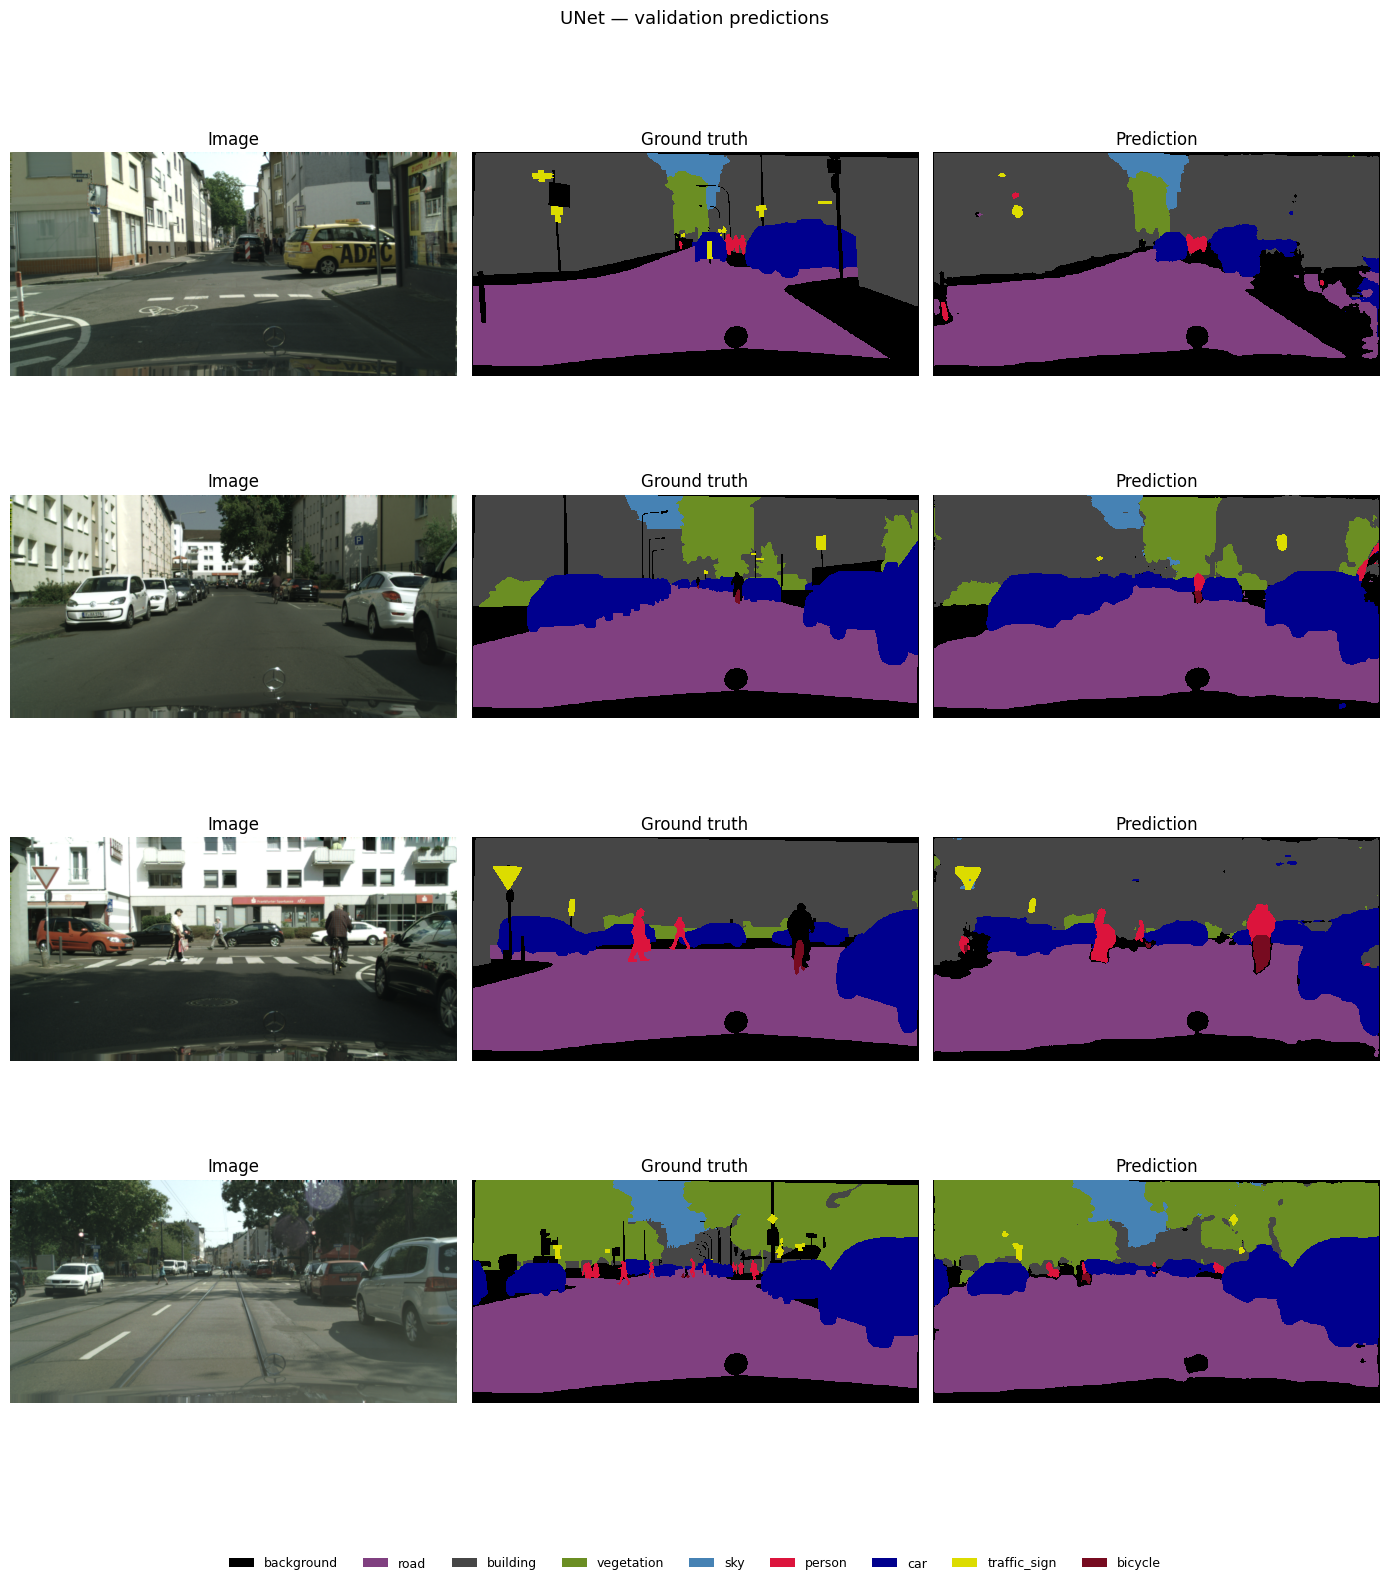

In [9]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# One distinct color per class (index 0 = background).
PALETTE = np.array([
    [  0,   0,   0],   # background
    [128,  64, 128],   # road
    [ 70,  70,  70],   # building
    [107, 142,  35],   # vegetation
    [ 70, 130, 180],   # sky
    [220,  20,  60],   # person
    [  0,   0, 142],   # car
    [220, 220,   0],   # traffic_sign
    [119,  11,  32],   # bicycle
], dtype=np.uint8)
CMAP = ListedColormap(PALETTE / 255.0)

# ImageNet stats used by the dataloader — needed to de-normalize for display.
_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def denormalize(img):
    """CHW normalized tensor -> HWC uint8-ready float in [0, 1]."""
    return (img.cpu() * _STD + _MEAN).clamp(0, 1).permute(1, 2, 0).numpy()


# Reload the best checkpoint so we visualize the *saved* model, not the last epoch.
if os.path.exists(CHECKPOINT_PATH):
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    print(f"Loaded best checkpoint: {CHECKPOINT_PATH}")
else:
    print("Checkpoint not found — visualizing the in-memory model.")

model.eval()
N_SAMPLES = 4
imgs, masks = next(iter(val_loader))
imgs_d = imgs.to(DEVICE)
with torch.no_grad():
    preds = model(imgs_d).argmax(dim=1).cpu()
gt = remap_mask(masks)

n = min(N_SAMPLES, imgs.shape[0])
fig, axes = plt.subplots(n, 3, figsize=(14, 4 * n))
if n == 1:
    axes = axes[None, :]
for i in range(n):
    axes[i, 0].imshow(denormalize(imgs[i]))
    axes[i, 0].set_title("Image")
    axes[i, 1].imshow(gt[i].numpy(),   cmap=CMAP, vmin=0, vmax=NUM_CLASSES - 1, interpolation="nearest")
    axes[i, 1].set_title("Ground truth")
    axes[i, 2].imshow(preds[i].numpy(), cmap=CMAP, vmin=0, vmax=NUM_CLASSES - 1, interpolation="nearest")
    axes[i, 2].set_title("Prediction")
    for ax in axes[i]:
        ax.axis("off")

legend = [Patch(facecolor=PALETTE[c] / 255.0, label=name) for c, name in enumerate(CLASS_NAMES)]
fig.legend(handles=legend, loc="lower center", ncol=NUM_CLASSES, fontsize=9, frameon=False)
fig.suptitle(f"{ARCHITECTURE} — validation predictions", fontsize=13)
plt.tight_layout(rect=[0, 0.04, 1, 0.98])
plt.show()

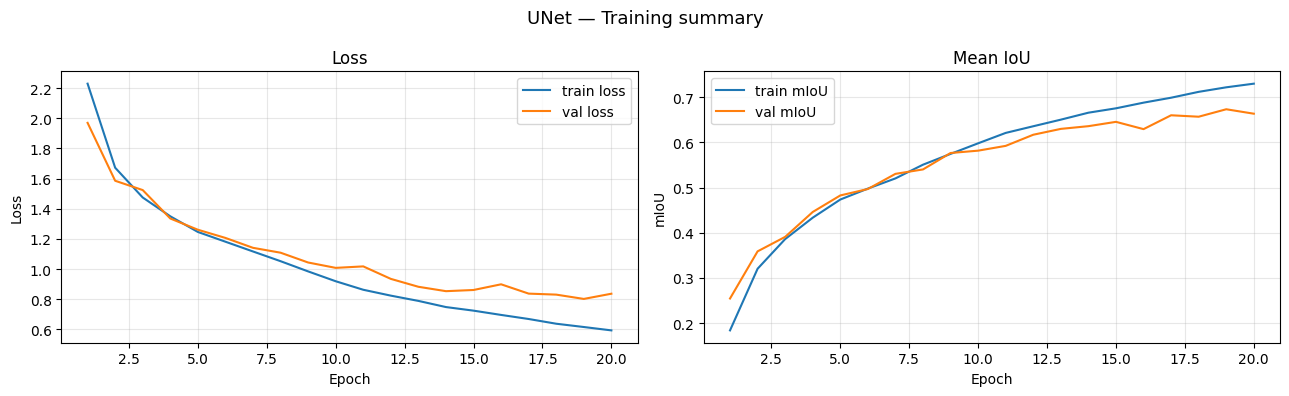

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"{ARCHITECTURE} — Training summary", fontsize=13)

epochs_ax = history["epoch"]

# Loss
axes[0].plot(epochs_ax, history["train_loss"], label="train loss")
axes[0].plot(epochs_ax, history["val_loss"],   label="val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

# mIoU
axes[1].plot(epochs_ax, history["train_mIoU"], label="train mIoU")
axes[1].plot(epochs_ax, history["val_mIoU"],   label="val mIoU")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("mIoU")
axes[1].set_title("Mean IoU"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

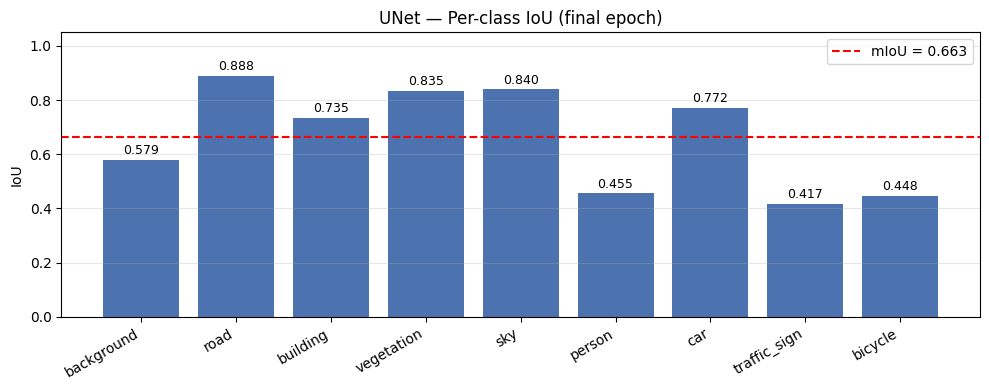

In [11]:
# Per-class IoU bar chart (final epoch)
final_iou = val_m.iou_per_class()
colors = ["#4c72b0" if not np.isnan(v) else "#cccccc" for v in final_iou]
values = [v if not np.isnan(v) else 0.0 for v in final_iou]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CLASS_NAMES, values, color=colors)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in values], padding=2, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("IoU")
ax.set_title(f"{ARCHITECTURE} — Per-class IoU (final epoch)")
ax.axhline(np.nanmean(final_iou), color="red", linestyle="--", label=f"mIoU = {np.nanmean(final_iou):.3f}")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 11. Class diagram (mermaid)

Structure of the classes defined in this notebook: the five segmentation
architectures (§5), the loss functions and the metrics helper (§4). All
networks subclass `torch.nn.Module`; `SegmentationMetrics` is a plain class.

```mermaid
classDiagram
    direction LR

    class nnModule {
        <<torch.nn.Module>>
        +forward(x)
    }

    class DoubleConv {
        +Sequential net
        +forward(x)
    }

    class UNet {
        +DoubleConv down1..down4
        +MaxPool2d pool1..pool4
        +DoubleConv bottleneck
        +ConvTranspose2d up1..up4
        +DoubleConv conv1..conv4
        +Conv2d out
        +forward(x)
    }

    class VGGUNet {
        +bool pretrained
        +Sequential enc1..enc5  (VGG16 features)
        +ConvTranspose2d up1..up5
        +DoubleConv dec2..dec5
        +Conv2d out
        +forward(x)
    }

    class SegNet {
        +Sequential enc1..enc5  (Conv-BN-ReLU)
        +MaxPool2d pool  (return_indices)
        +MaxUnpool2d unpool
        +Sequential dec1..dec5
        +forward(x)
    }

    class ResNetUNet {
        +int depth  (34 or 50)
        +bool pretrained
        +Sequential stem
        +Module layer1..layer4  (ResNet backbone)
        +ConvTranspose2d up0..up4
        +DoubleConv dec1..dec4
        +Conv2d out
        +forward(x)
    }

    class DiceLoss {
        +Tensor weights
        +float smooth
        +forward(logits, targets)
    }

    class CombinedLoss {
        +CrossEntropyLoss ce
        +DiceLoss dice
        +forward(logits, targets)
    }

    class SegmentationMetrics {
        +int num_classes
        +ndarray confusion
        +update(preds, targets)
        +pixel_accuracy()
        +iou_per_class()
        +mean_iou()
        +reset()
    }

    nnModule <|-- DoubleConv
    nnModule <|-- UNet
    nnModule <|-- VGGUNet
    nnModule <|-- SegNet
    nnModule <|-- ResNetUNet
    nnModule <|-- DiceLoss
    nnModule <|-- CombinedLoss

    UNet *-- DoubleConv : builds from
    VGGUNet *-- DoubleConv : decoder uses
    ResNetUNet *-- DoubleConv : decoder uses
    CombinedLoss *-- DiceLoss : CE + Dice
```
